### GOAL 
Notebook aims to disentangle HGSOC RNA data into 2+ data spaces (Cell Cycle Signal Space, Inteferon Signal Space, Cell Dissociation Signal Space, Cell Type Signal Space)

In [1]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '../../'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [3]:
from src.data.umi_data import UMIVaeDataset
from src.celluntangler import utils
from src.celluntangler.models import Trainer
from src.celluntangler.models.nb_vae import NBVAE
from src.visualization.helpers import split_embeddings
from src.visualization.visualization_functions import visualize_poincare_from_lorentz, visualize_embedding, visualize_2d

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# TODO - change path to actual data you care about
# TODO - debug getting HVG genes working with annotated dataframe
adata = sc.read_h5ad("../../../../data/synthetic/cophaser/synthethic_cc.h5ad")

In [5]:
adata.X = adata.layers["counts"]

##### Is the matrix sparse?

### Sanity-Checking the Data

### Pre-processing

In [6]:
adata.var["gene_symbols"] = adata.var.index

In [10]:
genes_process_sinusodial = np.array(['ANLN', 'ANP32E', 'ATAD2', 'AURKA', 'AURKB', 'BIRC5', 'BLM', 'BRIP1',
       'BUB1', 'CASP8AP2', 'CBX5', 'CCNB2', 'CCNE2', 'CDC20', 'CDC25C',
       'CDC45', 'CDC6', 'CDCA2', 'CDCA3', 'CDCA7', 'CDCA8', 'CDK1', 'CENPA',
       'CENPE', 'CENPF', 'CENPU', 'CHAF1B', 'CKAP2', 'CKAP2L', 'CKAP5',
       'CKS1B', 'CKS2', 'CLSPN', 'CTCF', 'DLGAP5', 'DSCC1', 'DTL', 'E2F8',
       'ECT2', 'ESCO2', 'EXO1', 'G2E3', 'GAS2L3', 'GINS2', 'GMNN', 'GTSE1',
       'HELLS', 'HJURP', 'HMGB2', 'HMMR', 'JPT1', 'KIF11', 'KIF20B', 'KIF23',
       'KIF2C', 'LBR', 'MCM2', 'MCM4', 'MCM5', 'MCM6', 'MKI67', 'MSH2', 'NASP',
       'NCAPD2', 'NDC80', 'NEK2', 'NUF2', 'NUSAP1', 'PCNA', 'PIMREG', 'POLA1',
       'POLD3', 'PRIM1', 'PSRC1', 'RAD51', 'RAD51AP1', 'RANGAP1', 'RFC2',
       'RPA2', 'RRM1', 'RRM2', 'SLBP', 'SMC4', 'TACC3', 'TIPIN', 'TMPO',
       'TOP2A', 'TPX2', 'TTK', 'TUBB4B', 'TYMS', 'UBE2C', 'UBR7', 'UHRF1',
       'UNG', 'USP1', 'WDR76'])

In [12]:
contained_genes_process_sinusodial = adata.var["gene_symbols"].isin(genes_process_sinusodial)

In [14]:
process_sinusodial_indices = np.where(contained_genes_process_sinusodial)[0]

all_known_indices = np.hstack((process_sinusodial_indices)) # TODO - modify all_known indices based on experiment that is being run 
remaining_indices = np.setdiff1d(np.arange(adata.shape[1]), all_known_indices)

rearranged_indices = np.hstack((process_sinusodial_indices, remaining_indices))
rearranged_indices = rearranged_indices.astype(int)

In [15]:
process_sinusodial_indices

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96])

In [16]:
adata.var_names

Index(['ANLN', 'ANP32E', 'ATAD2', 'AURKA', 'AURKB', 'BIRC5', 'BLM', 'BRIP1',
       'BUB1', 'CASP8AP2',
       ...
       'GENE_10087', 'GENE_10088', 'GENE_10089', 'GENE_10090', 'GENE_10091',
       'GENE_10092', 'GENE_10093', 'GENE_10094', 'GENE_10095', 'GENE_10096'],
      dtype='object', length=10097)

In [17]:
all_known_indices

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96])

In [18]:
process_sinusodial_indices

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96])

In [19]:
rearranged_indices

array([    0,     1,     2, ..., 10094, 10095, 10096])

In [20]:
adata = adata[:, rearranged_indices] # .copy() is safer in AnnData
adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!jj

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_48523/3340023796.py:2: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!jj


In [21]:
adata.var_names

Index(['ANLN', 'ANP32E', 'ATAD2', 'AURKA', 'AURKB', 'BIRC5', 'BLM', 'BRIP1',
       'BUB1', 'CASP8AP2',
       ...
       'GENE_10087', 'GENE_10088', 'GENE_10089', 'GENE_10090', 'GENE_10091',
       'GENE_10092', 'GENE_10093', 'GENE_10094', 'GENE_10095', 'GENE_10096'],
      dtype='object', length=10097)

In [23]:
# Creating (Disjoint) Masks
mask_sinusodial = np.zeros(adata.n_vars)
mask_sinusodial[adata.var["gene_symbols"].isin(genes_process_sinusodial)] = 1

mask_all = np.ones(adata.n_vars)
mask_all[adata.var["gene_symbols"].isin(genes_process_sinusodial)] = 0 

mask = torch.tensor([mask_sinusodial, mask_all])

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_48523/1583264970.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  mask = torch.tensor([mask_sinusodial, mask_all])


In [24]:
mask

tensor([[1., 1., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 1., 1.]], dtype=torch.float64)

In [25]:
np.count_nonzero(mask_sinusodial)

97

In [26]:
adata.X.shape

(10000, 10097)

In [32]:
sinusodial_genes_potentially = adata.X[:,mask_sinusodial.astype(bool)].todense()

In [33]:
sinusodial_genes_potentially

matrix([[0, 0, 1, ..., 1, 1, 1],
        [0, 3, 0, ..., 0, 1, 1],
        [9, 2, 2, ..., 0, 1, 0],
        ...,
        [0, 1, 0, ..., 0, 0, 0],
        [5, 1, 0, ..., 0, 1, 0],
        [4, 1, 7, ..., 0, 1, 0]])

In [34]:
X = sinusodial_genes_potentially
X = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(X, full_matrices=False)
pc1 = U[:, 0]

In [35]:
z = adata.obsm['ground_truth_z'][:,1]
plt.scatter(z, U[:, 0], s=5)
plt.xlabel("Z (Sinusodial)")
plt.ylabel("PC1")
plt.show()

KeyError: 'ground_truth_z'

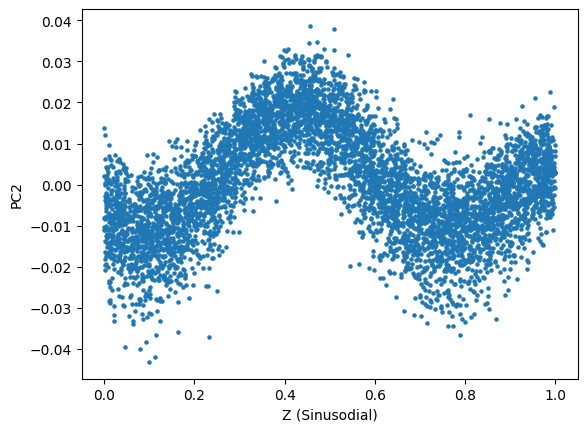

In [32]:
z = adata.obsm['ground_truth_z'][:,1]
plt.scatter(z, U[:, 1], s=5)
plt.xlabel("Z (Sinusodial)")
plt.ylabel("PC2")
plt.show()

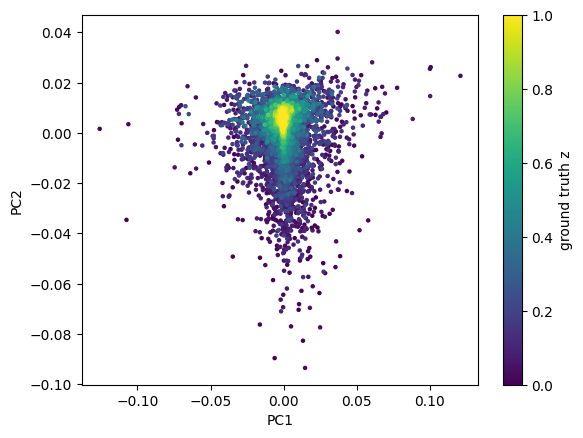

In [55]:
z = adata.obs['latent_coordinate'].to_numpy()
PC1 = np.array(U[:,1]).squeeze()
PC2 = np.array(U[:,2]).squeeze()
sc = plt.scatter(PC1, PC2, s=5, c= z)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(sc, label="ground truth z")
plt.show()

In [48]:
z.shape

(10000,)

In [54]:
np.array(U[:,1]).squeeze()

array([-0.00330776, -0.10751188,  0.03952478, ..., -0.00073278,
        0.00068892, -0.00177324])

In [47]:
adata.obs['latent_coordinate'].to_numpy()

array([0.00000000e+00, 1.00010001e-04, 2.00020002e-04, ...,
       9.99799980e-01, 9.99899990e-01, 1.00000000e+00])

Text(0, 0.5, 'PC1')

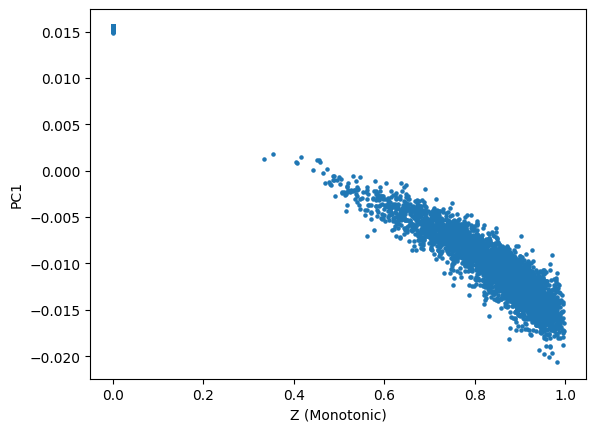

In [38]:
mask_monotonic = np.zeros(adata.n_vars)
mask_monotonic[adata.var["gene_symbols"].isin(genes_process_monotonic)] = 1
monotone_genes_potentially = adata.X[:,mask_monotonic.astype(bool)]

X = monotone_genes_potentially
X = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(X, full_matrices=False)
pc1 = U[:, 0]

z = adata.obsm['ground_truth_z'][:,0]
plt.scatter(z, pc1, s=5)
plt.xlabel("Z (Monotonic)")
plt.ylabel("PC1")

### Configure Save Paths

In [41]:
epoch_embeddings_save_path = "/Users/jeromecho/onedrive/Thesis/thesis/results/benchmarking/synthetic/02_03_experiment_set_1/celluntangler_r2_e10"
visualize_information={}
# The epochs to save the intermediate embeddings for
visualize_information["epochs"]=[i for i in range(0, 500, 50)] 
visualize_information["x"]=x
visualize_information["y"]=y
visualize_information["embeddings_save_path"]=epoch_embeddings_save_path
visualize_information["model_name"]=config.model_name
visualize_information["device"]=config.device

### Model Creation

In [42]:
use_gpu = False
if use_gpu:
  print("Using GPU")
  config.device = torch.device("cuda")
else:
  print("Using CPU")
  config.device = torch.device("cpu")

Using CPU


In [43]:
torch.set_default_dtype(torch.float64)

In [44]:
model = NBVAE(h_dim=config.h_dim,
              components=components,
              mask=mask,
              dataset=dataset,
              config=config).to(config.device)

Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
RotatedHyperbolicComponent(R^3)


### Training

In [ ]:
trainer = Trainer(model)

optimizer = trainer.build_optimizer(learning_rate=config.learning_rate,
                                        fixed_curvature=config.fixed_curvature,
                                        use_adamw=config.use_adamw,
                                        weight_decay=config.weight_decay)

betas = utils.linear_betas(config.start,
                           config.end,
                           end_epoch=config.end_epoch,
                           epochs=config.epochs)


trainer.train_epochs(optimizer=optimizer,
                       train_data=train_loader,
                       betas=betas,
                       likelihood_n=0,
                       max_epochs=config.max_epochs,
                       patience=100,
                       visualize_information=visualize_information)

initialized early stopper
	TrainEpoch 0:	{'bce': -1062.712, 'kl': 2.593, 'elbo': -1065.305, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 1:	{'bce': -1061.788, 'kl': 2.7, 'elbo': -1064.488, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 2:	{'bce': -1061.762, 'kl': 2.748, 'elbo': -1064.51, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 3:	{'bce': -1061.656, 'kl': 2.673, 'elbo': -1064.329, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 4:	{'bce': -1061.622, 'kl': 2.568, 'elbo': -1064.19, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 5:	{'bce': -1061.587, 'kl': 2.454, 'elbo': -1064.042, 'll': 0.0, '

### Saving Embeddings

In [47]:
embeddings_save_path = epoch_embeddings_save_path

In [48]:
checkpoint = torch.load(
    os.path.join(embeddings_save_path,  f"{model_name}_best_model.pt"),
    map_location=config.device
)
model.load_state_dict(checkpoint["model_state"])
model.eval()

NBVAE(
  (components): ModuleList(
    (0): RotatedHyperbolicComponent(R^3)
    (1): EuclideanComponent(R^10)
  )
  (encoder): Sequential(
    (0): Linear(in_features=1000, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): GELU(approximate='none')
  )
  (decoder): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): GELU(approximate='none')
  )
  (fc_mu): Linear(in_features=128, out_features=1000, bias=True)
  (fc_sigma): Linear(in_features=128, out_features=1000, bias=True)
)

In [49]:
a = model(torch.log1p(torch.tensor(x, device=config.device)), torch.tensor(y, device=config.device))
np.savetxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params_best.txt'), a[4].detach().to(torch.device("cpu")).numpy())

### Analysis

In [50]:
gene_expression_matrix_path = epoch_embeddings_save_path

In [51]:
embeddings = np.loadtxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params_best.txt'))
component_embeddings = split_embeddings(model_name, embeddings)
for c in component_embeddings:
    adata.obsm[c] = component_embeddings[c]

r2 3
e10 10


In [52]:
embeddings_save_path

'/Users/jeromecho/onedrive/Thesis/thesis/results/benchmarking/synthetic/02_03_experiment_set_1/celluntangler_r2_e10'

#### Visualization of Component 1 (R2)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/CellUntangler/src/visualization/visualization_functions.py:266: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=bbox_to_anchor)


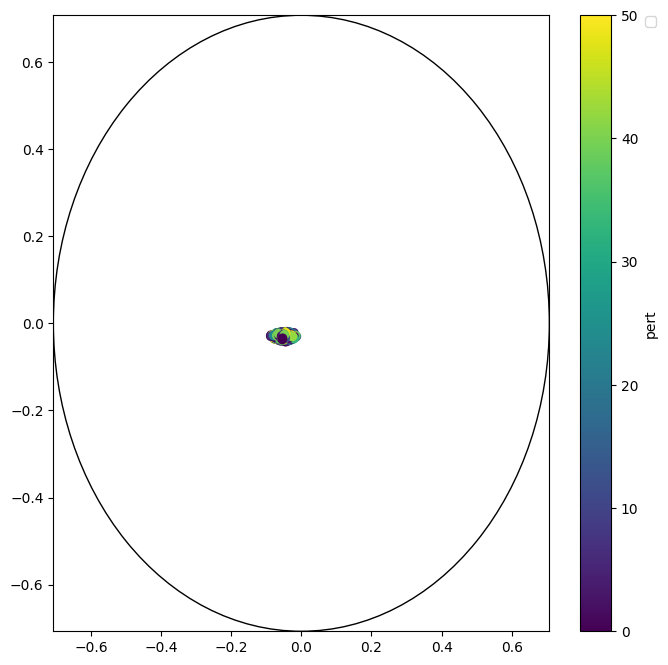

In [53]:
embeddings_key = "component1_r2"
desired_obs = 'pert'
desired_obs_all = adata.obs[desired_obs]
legend_coordinates = (1.23,1.01)
fig = visualize_poincare_from_lorentz(adata.obsm[embeddings_key],
                       desired_obs_all,
                       curvature=-2,
                      embedding_type='continuous',
                       cmap=plt.cm.viridis,
                       cat_colors=None,
                      grid_lines=True,
                      c_bar_label=desired_obs,
                      bbox_to_anchor=legend_coordinates)

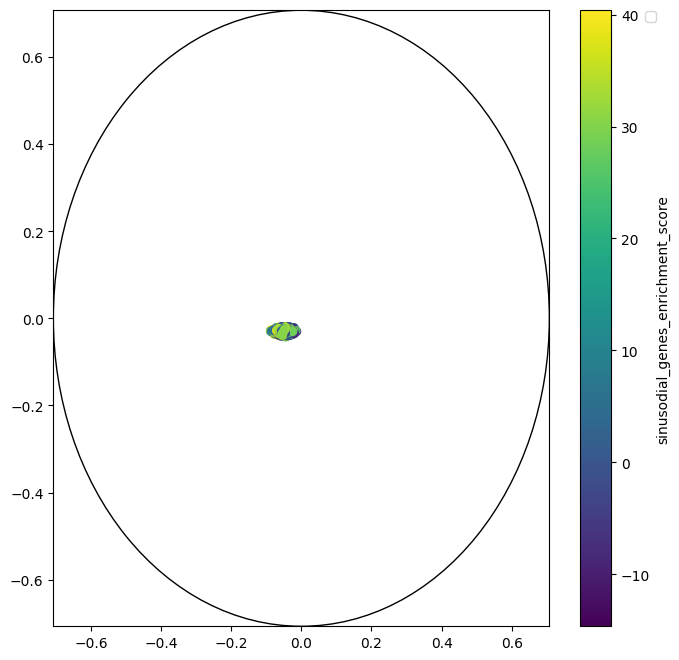

In [54]:
embeddings_key = "component1_r2"
desired_obs = 'sinusodial_genes_enrichment_score'
desired_obs_all = adata.obs[desired_obs]
legend_coordinates = (1.23,1.01)
fig = visualize_poincare_from_lorentz(adata.obsm[embeddings_key],
                       desired_obs_all,
                       curvature=-2,
                      embedding_type='continuous',
                       cmap=plt.cm.viridis,
                       cat_colors=None,
                      grid_lines=True,
                      c_bar_label=desired_obs,
                      bbox_to_anchor=legend_coordinates)

Text(0.5, 1.0, 'Sinusodial Genes Enrichment Score Distribution')

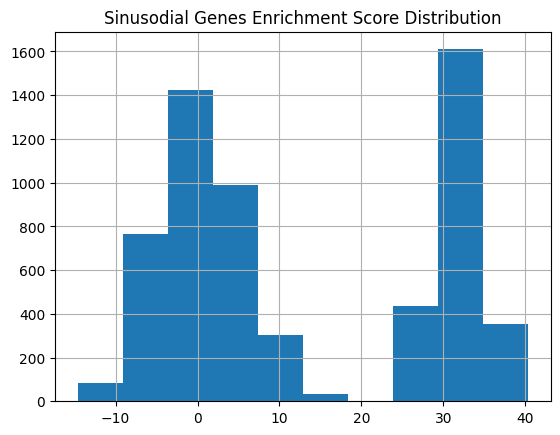

In [62]:
ax = adata.obs["sinusodial_genes_enrichment_score"].hist()
ax.set_title("Sinusodial Genes Enrichment Score Distribution")

#### Visualization of Component 2 (E2)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


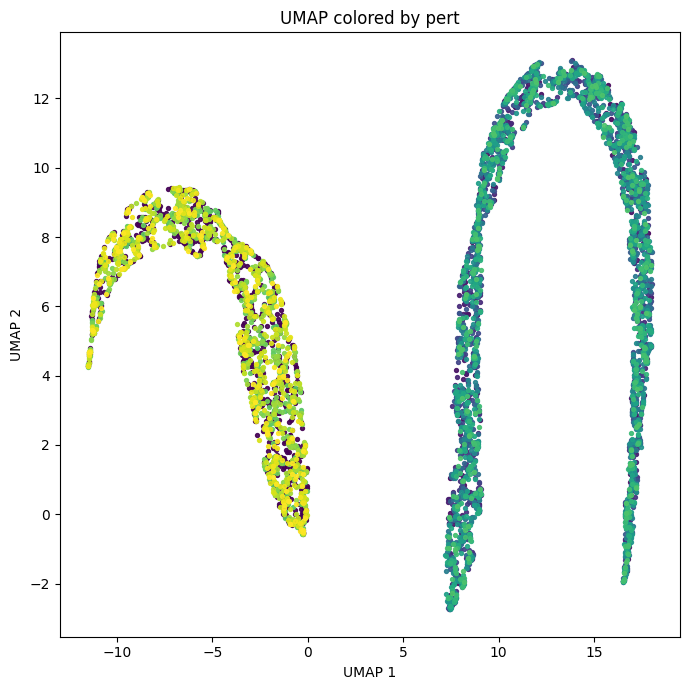

In [63]:
embeddings_key = "component2_e10"
desired_obs = 'pert'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


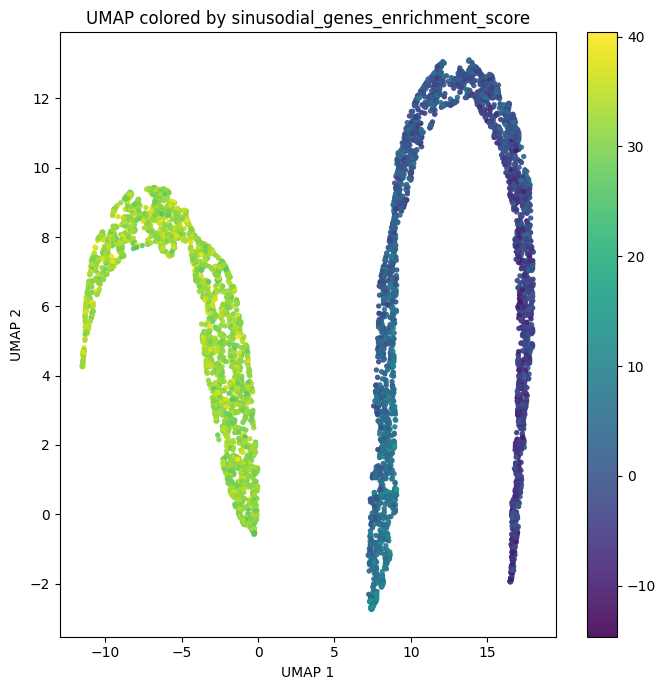

In [64]:
embeddings_key = "component2_e10"
desired_obs = 'sinusodial_genes_enrichment_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)